<a href="https://colab.research.google.com/github/aabyyaann/Practical-Linear-Algebra-for-Data-Science/blob/main/Chapter9_Orthogonal_Matrices_and_QR_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9 — Orthogonal Matrices and QR Decomposition

## Tujuan Chapter
Pada chapter ini, kita mempelajari dua konsep penting dalam aljabar linear:

1. **Orthogonal matrices (matriks ortogonal)**
2. **QR decomposition**

Kedua topik ini sangat penting karena sering digunakan dalam:
- penyelesaian sistem linear
- least squares regression
- stabilitas komputasi numerik
- dekomposisi matriks
- machine learning dan data science

---

## Fokus pembahasan
Pada notebook ini kita akan mempelajari:

- pengertian vektor ortogonal dan ortonormal
- pengertian matriks ortogonal
- sifat-sifat matriks ortogonal
- hubungan transpose dan invers pada matriks ortogonal
- norm preservation (panjang vektor tetap)
- dot product preservation
- dekomposisi QR
- interpretasi matriks **Q** dan **R**
- penggunaan QR decomposition untuk menyelesaikan sistem linear
- hubungan QR dengan least squares

# Ringkasan Teori

## 1. Vektor ortogonal
Dua vektor dikatakan **ortogonal** jika hasil dot product-nya sama dengan nol:

\[
\mathbf{u}^T \mathbf{v} = 0
\]

Artinya, kedua vektor saling tegak lurus.

---

## 2. Vektor ortonormal
Sekumpulan vektor disebut **ortonormal** jika:
1. setiap pasangan vektor saling ortogonal
2. setiap vektor memiliki panjang (norm) = 1

---

## 3. Matriks ortogonal
Sebuah matriks \( Q \) disebut **orthogonal matrix** jika kolom-kolomnya ortonormal, atau memenuhi:

\[
Q^T Q = I
\]

dan juga:

\[
Q Q^T = I
\]

Karena itu, berlaku sifat penting:

\[
Q^{-1} = Q^T
\]

Ini adalah salah satu alasan mengapa matriks ortogonal sangat istimewa.

---

## 4. Mengapa matriks ortogonal penting?
Matriks ortogonal:
- mempertahankan panjang vektor
- mempertahankan sudut
- mempertahankan dot product
- lebih stabil secara numerik
- sangat penting dalam QR decomposition, PCA, SVD, dan least squares

---

## 5. QR decomposition
QR decomposition memfaktorkan sebuah matriks \( A \) menjadi:

\[
A = QR
\]

dengan:
- \( Q \) = matriks ortogonal / ortonormal
- \( R \) = matriks segitiga atas (*upper triangular*)

QR decomposition sangat berguna untuk:
- menyelesaikan sistem linear
- least squares
- komputasi numerik yang lebih stabil daripada inverse langsung

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

In [2]:
u = np.array([1, 2], dtype=float)
v = np.array([2, -1], dtype=float)

dot_uv = np.dot(u, v)

print("u =", u)
print("v =", v)
print("dot(u, v) =", dot_uv)

u = [1. 2.]
v = [ 2. -1.]
dot(u, v) = 0.0


## Penjelasan
Jika `dot(u, v) = 0`, maka vektor \(u\) dan \(v\) saling tegak lurus.

Pada contoh ini:
\[
1 \cdot 2 + 2 \cdot (-1) = 2 - 2 = 0
\]

jadi kedua vektor tersebut ortogonal.

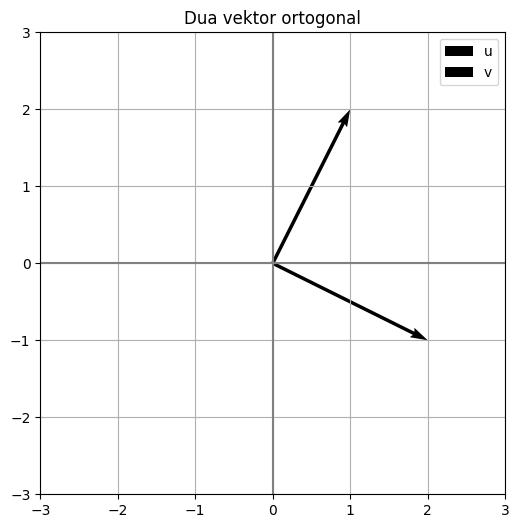

In [3]:
plt.figure(figsize=(6,6))
plt.axhline(0, color='gray')
plt.axvline(0, color='gray')

plt.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, label='u')
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, label='v')

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.grid(True)
plt.legend()
plt.title("Dua vektor ortogonal")
plt.show()

# 2. Normalisasi vektor

Agar sebuah vektor menjadi **unit vector**, kita membagi vektor dengan norm-nya:

\[
\hat{u} = \frac{u}{\|u\|}
\]

Vektor hasil normalisasi memiliki panjang 1.

In [4]:
u = np.array([3, 4], dtype=float)

u_norm = np.linalg.norm(u)
u_unit = u / u_norm

print("u =", u)
print("norm(u) =", u_norm)
print("u_unit =", u_unit)
print("norm(u_unit) =", np.linalg.norm(u_unit))

u = [3. 4.]
norm(u) = 5.0
u_unit = [0.6 0.8]
norm(u_unit) = 1.0


# 3. Sekumpulan vektor ortonormal

Sekarang kita buat dua vektor yang:
1. saling ortogonal
2. masing-masing panjangnya 1

Ini disebut **orthonormal vectors**.

In [5]:
q1 = np.array([1, 0], dtype=float)
q2 = np.array([0, 1], dtype=float)

print("q1 =", q1)
print("q2 =", q2)

print("\nDot product q1·q2 =", np.dot(q1, q2))
print("Norm q1 =", np.linalg.norm(q1))
print("Norm q2 =", np.linalg.norm(q2))

q1 = [1. 0.]
q2 = [0. 1.]

Dot product q1·q2 = 0.0
Norm q1 = 1.0
Norm q2 = 1.0


## Interpretasi
- dot product = 0 → ortogonal
- norm = 1 → unit vector

Karena dua syarat ini terpenuhi, maka \(q_1\) dan \(q_2\) adalah vektor ortonormal.

## Interpretasi
- dot product = 0 → ortogonal
- norm = 1 → unit vector

Karena dua syarat ini terpenuhi, maka \(q_1\) dan \(q_2\) adalah vektor ortonormal.

In [6]:
Q = np.column_stack((q1, q2))

print("Matriks Q:")
print(Q)

Matriks Q:
[[1. 0.]
 [0. 1.]]


In [7]:
print("Q^T Q =")
print(Q.T @ Q)

print("\nQ Q^T =")
print(Q @ Q.T)

Q^T Q =
[[1. 0.]
 [0. 1.]]

Q Q^T =
[[1. 0.]
 [0. 1.]]


## Penjelasan
Untuk matriks ortogonal berlaku:

\[
Q^TQ = I
\]

dan juga

\[
QQ^T = I
\]

Karena kolom-kolom pada \(Q\) ortonormal.

# 5. Contoh matriks ortogonal non-trivial

Matriks identitas memang ortogonal, tetapi terlalu sederhana.
Sekarang kita gunakan matriks rotasi 2D.

Matriks rotasi sudut \(\theta\):

\[
Q =
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\]

Matriks ini adalah contoh klasik matriks ortogonal.

In [8]:
theta = np.deg2rad(30)

Q = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

print("Q =")
print(Q)

Q =
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]


In [9]:
print("Q^T Q =")
print(Q.T @ Q)

print("\nApakah mendekati identity?")
print(np.allclose(Q.T @ Q, np.eye(2)))

Q^T Q =
[[1. 0.]
 [0. 1.]]

Apakah mendekati identity?
True


# 6. Sifat penting: invers = transpose

Untuk matriks ortogonal berlaku:

\[
Q^{-1} = Q^T
\]

Kita cek secara numerik.

In [10]:
Q_inv = np.linalg.inv(Q)

print("Q inverse:")
print(Q_inv)

print("\nQ transpose:")
print(Q.T)

print("\nApakah Q_inv sama dengan Q.T ?")
print(np.allclose(Q_inv, Q.T))

Q inverse:
[[ 0.866  0.5  ]
 [-0.5    0.866]]

Q transpose:
[[ 0.866  0.5  ]
 [-0.5    0.866]]

Apakah Q_inv sama dengan Q.T ?
True


## Makna penting
Biasanya menghitung invers matriks cukup mahal.  
Namun untuk matriks ortogonal, kita tidak perlu menghitung invers secara umum, karena:

\[
Q^{-1} = Q^T
\]

Ini membuat matriks ortogonal sangat efisien dan stabil secara numerik.

# 7. Orthogonal matrices preserve norm

Jika \(Q\) ortogonal, maka panjang vektor tidak berubah setelah dikalikan oleh \(Q\).

Jika:

\[
y = Qx
\]

maka:

\[
\|y\| = \|x\|
\]

Mari kita cek.

In [11]:
x = np.array([3, 1], dtype=float)
y = Q @ x

print("x =", x)
print("Q @ x =", y)

print("\n||x|| =", np.linalg.norm(x))
print("||Qx|| =", np.linalg.norm(y))

x = [3. 1.]
Q @ x = [2.0981 2.366 ]

||x|| = 3.1622776601683795
||Qx|| = 3.162277660168379


In [12]:
print("Apakah norm sama?")
print(np.allclose(np.linalg.norm(x), np.linalg.norm(y)))

Apakah norm sama?
True


## Penjelasan
Matriks ortogonal hanya mengubah orientasi (misalnya rotasi atau refleksi), tetapi **tidak mengubah panjang vektor**.
Inilah sebabnya matriks ortogonal sangat penting dalam geometri dan machine learning.

## Penjelasan
Matriks ortogonal hanya mengubah orientasi (misalnya rotasi atau refleksi), tetapi **tidak mengubah panjang vektor**.
Inilah sebabnya matriks ortogonal sangat penting dalam geometri dan machine learning.

In [13]:
x1 = np.array([1, 2], dtype=float)
x2 = np.array([2, 1], dtype=float)

y1 = Q @ x1
y2 = Q @ x2

dot_before = np.dot(x1, x2)
dot_after = np.dot(y1, y2)

print("dot sebelum transformasi =", dot_before)
print("dot sesudah transformasi =", dot_after)
print("Apakah sama?", np.allclose(dot_before, dot_after))

dot sebelum transformasi = 4.0
dot sesudah transformasi = 4.0
Apakah sama? True


# 9. Visualisasi rotasi oleh matriks ortogonal

Kita lihat bagaimana matriks rotasi memutar vektor tetapi tetap menjaga panjangnya.

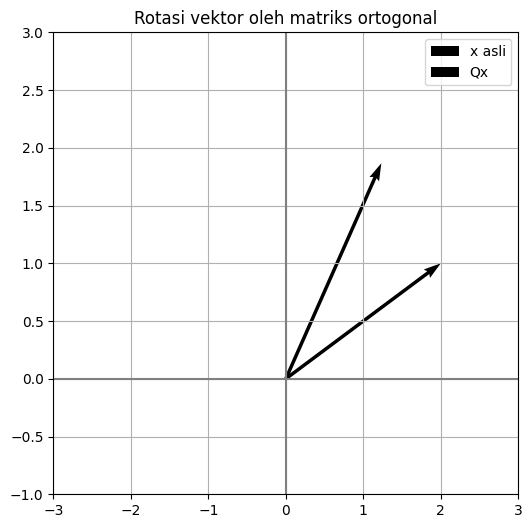

In [14]:
x = np.array([2, 1], dtype=float)
y = Q @ x

plt.figure(figsize=(6,6))
plt.axhline(0, color='gray')
plt.axvline(0, color='gray')

plt.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, label='x asli')
plt.quiver(0, 0, y[0], y[1], angles='xy', scale_units='xy', scale=1, label='Qx')

plt.xlim(-3, 3)
plt.ylim(-1, 3)
plt.grid(True)
plt.legend()
plt.title("Rotasi vektor oleh matriks ortogonal")
plt.show()

# 10. Masuk ke QR Decomposition

QR decomposition memecah matriks \(A\) menjadi:

\[
A = QR
\]

dengan:
- \(Q\) = matriks dengan kolom-kolom ortonormal
- \(R\) = matriks segitiga atas

Kita mulai dari sebuah matriks contoh.

In [15]:
A = np.array([
    [1, 1],
    [1, 0],
    [0, 1]
], dtype=float)

print("Matriks A:")
print(A)
print("Shape A:", A.shape)

Matriks A:
[[1. 1.]
 [1. 0.]
 [0. 1.]]
Shape A: (3, 2)


In [16]:
Q, R = np.linalg.qr(A)

print("Q =")
print(Q)

print("\nR =")
print(R)

Q =
[[-0.7071  0.4082]
 [-0.7071 -0.4082]
 [-0.      0.8165]]

R =
[[-1.4142 -0.7071]
 [ 0.      1.2247]]


# 11. Memverifikasi hasil QR decomposition

Jika QR decomposition benar, maka:

\[
A = QR
\]

Mari kita cek hasil perkalian \(Q @ R\).

In [17]:
A_reconstructed = Q @ R

print("Q @ R =")
print(A_reconstructed)

print("\nApakah sama dengan A?")
print(np.allclose(A, A_reconstructed))

Q @ R =
[[ 1.  1.]
 [ 1. -0.]
 [ 0.  1.]]

Apakah sama dengan A?
True


# 12. Memeriksa apakah Q ortogonal / ortonormal

Pada QR decomposition, matriks \(Q\) seharusnya memiliki kolom ortonormal.
Kita cek dengan:

\[
Q^TQ = I
\]

In [18]:
print("Q^T Q =")
print(Q.T @ Q)

print("\nApakah mendekati identity?")
print(np.allclose(Q.T @ Q, np.eye(Q.shape[1])))

Q^T Q =
[[1. 0.]
 [0. 1.]]

Apakah mendekati identity?
True


# 13. Melihat bentuk matriks R

Matriks \(R\) hasil QR decomposition berbentuk **upper triangular**.
Artinya elemen-elemen di bawah diagonal utama bernilai 0 (atau sangat dekat 0 secara numerik).

In [19]:
print("R =")
print(R)

R =
[[-1.4142 -0.7071]
 [ 0.      1.2247]]


## Interpretasi
Dalam dekomposisi:

\[
A = QR
\]

- **Q** berisi basis ortonormal
- **R** menyimpan koefisien kombinasi linear yang membentuk kembali \(A\)

Secara intuitif:
- Q = “arah baru” yang saling tegak lurus
- R = “berapa banyak kontribusi tiap arah”

# 14. QR decomposition pada matriks persegi

Sekarang kita coba QR decomposition pada matriks 3x3.

In [20]:
B = np.array([
    [1, 2, 0],
    [2, 1, 1],
    [0, 1, 2]
], dtype=float)

print("B =")
print(B)

B =
[[1. 2. 0.]
 [2. 1. 1.]
 [0. 1. 2.]]


In [21]:
Qb, Rb = np.linalg.qr(B)

print("Qb =")
print(Qb)

print("\nRb =")
print(Rb)

Qb =
[[-0.4472  0.7171 -0.5345]
 [-0.8944 -0.3586  0.2673]
 [-0.      0.5976  0.8018]]

Rb =
[[-2.2361 -1.7889 -0.8944]
 [ 0.      1.6733  0.8367]
 [ 0.      0.      1.8708]]


In [22]:
print("Qb @ Rb =")
print(Qb @ Rb)

print("\nApakah sama dengan B?")
print(np.allclose(B, Qb @ Rb))

Qb @ Rb =
[[ 1.  2. -0.]
 [ 2.  1.  1.]
 [ 0.  1.  2.]]

Apakah sama dengan B?
True


# 15. Menyelesaikan sistem linear dengan QR decomposition

Misalkan kita ingin menyelesaikan:

\[
Ax = b
\]

Jika \(A = QR\), maka:

\[
QRx = b
\]

Kalikan kedua sisi dengan \(Q^T\):

\[
Rx = Q^Tb
\]

Karena \(R\) adalah upper triangular, sistem ini lebih mudah diselesaikan.

In [23]:
A = np.array([
    [2, 1],
    [1, 3]
], dtype=float)

b = np.array([1, 2], dtype=float)

print("A =")
print(A)
print("\nb =", b)

A =
[[2. 1.]
 [1. 3.]]

b = [1. 2.]


In [24]:
Q, R = np.linalg.qr(A)

print("Q =")
print(Q)
print("\nR =")
print(R)

Q =
[[-0.8944 -0.4472]
 [-0.4472  0.8944]]

R =
[[-2.2361 -2.2361]
 [ 0.      2.2361]]


In [25]:
# Hitung Q^T b
qtb = Q.T @ b

print("Q^T b =")
print(qtb)

Q^T b =
[-1.7889  1.3416]


In [26]:
# Selesaikan Rx = Q^T b
x_qr = np.linalg.solve(R, qtb)

print("Solusi x via QR decomposition:")
print(x_qr)

Solusi x via QR decomposition:
[0.2 0.6]


In [27]:
# Selesaikan Rx = Q^T b
x_qr = np.linalg.solve(R, qtb)

print("Solusi x via QR decomposition:")
print(x_qr)

Solusi x via QR decomposition:
[0.2 0.6]


# 16. Hubungan QR decomposition dengan least squares

Salah satu penggunaan paling penting QR decomposition adalah menyelesaikan **least squares problem**.

Jika sistem:
\[
Ax \approx b
\]

tidak punya solusi eksak karena jumlah persamaan lebih banyak daripada jumlah variabel, maka kita mencari \(x\) terbaik yang meminimalkan error.

QR decomposition sangat berguna karena lebih stabil dibanding menghitung:

\[
(A^TA)^{-1}A^Tb
\]

# 17. Contoh least squares sederhana

Kita buat sistem overdetermined:
- 3 persamaan
- 2 variabel

Lalu kita cari solusi least squares menggunakan QR decomposition.

In [28]:
A = np.array([
    [1, 1],
    [1, 2],
    [1, 3]
], dtype=float)

b = np.array([1, 2, 2], dtype=float)

print("A =")
print(A)
print("\nb =", b)

A =
[[1. 1.]
 [1. 2.]
 [1. 3.]]

b = [1. 2. 2.]


In [29]:
Q, R = np.linalg.qr(A)

print("Q =")
print(Q)
print("\nR =")
print(R)

Q =
[[-0.5774  0.7071]
 [-0.5774  0.    ]
 [-0.5774 -0.7071]]

R =
[[-1.7321 -3.4641]
 [ 0.     -1.4142]]


In [30]:
# Least squares via numpy
x_lstsq, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

print("Solusi least squares:")
print(x_lstsq)

print("\nResiduals:")
print(residuals)

Solusi least squares:
[0.6667 0.5   ]

Residuals:
[0.1667]


# Least squares via numpy
x_lstsq, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

print("Solusi least squares:")
print(x_lstsq)

print("\nResiduals:")
print(residuals)

# 18. Memeriksa kolom-kolom Q pada hasil QR

Kolom-kolom pada Q seharusnya ortonormal.
Kita bisa memeriksa:
- norm tiap kolom
- dot product antar kolom

In [31]:
A = np.array([
    [1, 1],
    [1, 0],
    [0, 1]
], dtype=float)

Q, R = np.linalg.qr(A)

print("Q =")
print(Q)

Q =
[[-0.7071  0.4082]
 [-0.7071 -0.4082]
 [-0.      0.8165]]


In [32]:
col1 = Q[:, 0]
col2 = Q[:, 1]

print("Kolom 1 Q:", col1)
print("Kolom 2 Q:", col2)

print("\nNorm kolom 1:", np.linalg.norm(col1))
print("Norm kolom 2:", np.linalg.norm(col2))

print("\nDot product antar kolom:", np.dot(col1, col2))

Kolom 1 Q: [-0.7071 -0.7071 -0.    ]
Kolom 2 Q: [ 0.4082 -0.4082  0.8165]

Norm kolom 1: 0.9999999999999998
Norm kolom 2: 1.0

Dot product antar kolom: 1.1102230246251565e-16


## Interpretasi
Jika:
- norm kolom = 1
- dot product antar kolom = 0

maka kolom-kolom Q benar-benar ortonormal.

# 19. Visualisasi dua kolom ortonormal dari Q

Untuk contoh 3x2, kita bisa melihat dua kolom Q sebagai dua arah basis ortonormal dalam ruang hasil transformasi.

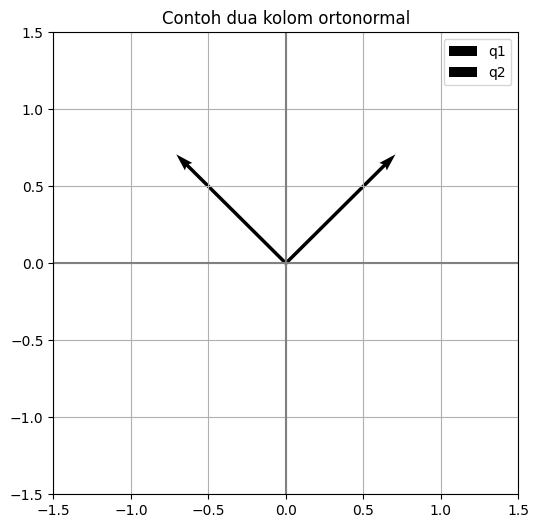

In [33]:
plt.figure(figsize=(6,6))
plt.axhline(0, color='gray')
plt.axvline(0, color='gray')

# ambil contoh visual 2D sederhana dari matriks ortogonal rotasi
theta = np.deg2rad(45)
Q2 = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

q1 = Q2[:,0]
q2 = Q2[:,1]

plt.quiver(0, 0, q1[0], q1[1], angles='xy', scale_units='xy', scale=1, label='q1')
plt.quiver(0, 0, q2[0], q2[1], angles='xy', scale_units='xy', scale=1, label='q2')

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()
plt.title("Contoh dua kolom ortonormal")
plt.show()

# 20. Mini eksperimen: QR decomposition pada beberapa matriks acak

Sekarang kita uji beberapa matriks acak dan periksa:
1. apakah \(A \approx QR\)
2. apakah \(Q^TQ \approx I\)

In [34]:
np.random.seed(42)

for i in range(3):
    A = np.random.randn(4, 3)
    Q, R = np.linalg.qr(A)

    ok_reconstruct = np.allclose(A, Q @ R)
    ok_orthogonal = np.allclose(Q.T @ Q, np.eye(Q.shape[1]))

    print(f"\n=== Percobaan {i+1} ===")
    print("Shape A:", A.shape)
    print("A ≈ QR ?", ok_reconstruct)
    print("Q^TQ ≈ I ?", ok_orthogonal)


=== Percobaan 1 ===
Shape A: (4, 3)
A ≈ QR ? True
Q^TQ ≈ I ? True

=== Percobaan 2 ===
Shape A: (4, 3)
A ≈ QR ? True
Q^TQ ≈ I ? True

=== Percobaan 3 ===
Shape A: (4, 3)
A ≈ QR ? True
Q^TQ ≈ I ? True


# 21. Analisis hasil chapter

Dari seluruh eksperimen pada chapter ini, kita bisa menarik beberapa poin penting:

## A. Matriks ortogonal memiliki kolom ortonormal
Artinya:
- setiap kolom panjangnya 1
- setiap pasangan kolom saling tegak lurus

## B. Sifat utama matriks ortogonal
Jika \(Q\) ortogonal, maka:
\[
Q^TQ = I
\]
dan:
\[
Q^{-1} = Q^T
\]

## C. Matriks ortogonal mempertahankan struktur geometri
Mereka menjaga:
- panjang vektor
- sudut
- dot product

## D. QR decomposition memfaktorkan matriks menjadi:
\[
A = QR
\]

dengan:
- Q = basis ortonormal
- R = matriks segitiga atas

## E. QR decomposition sangat penting untuk least squares
QR decomposition adalah salah satu alat utama dalam:
- regresi linear
- komputasi numerik stabil
- pemecahan sistem linear
- machine learning

# Kesimpulan Chapter 9

Pada chapter ini kita mempelajari **Orthogonal Matrices and QR Decomposition**, dua konsep yang sangat penting dalam aljabar linear modern.

## Ringkasan poin utama:
1. dua vektor ortogonal memiliki dot product = 0
2. vektor ortonormal adalah vektor ortogonal yang masing-masing bernorm 1
3. matriks ortogonal memiliki kolom ortonormal dan memenuhi:
   \[
   Q^TQ = I
   \]
4. untuk matriks ortogonal berlaku:
   \[
   Q^{-1} = Q^T
   \]
5. matriks ortogonal mempertahankan panjang vektor dan dot product
6. QR decomposition memecah matriks menjadi:
   \[
   A = QR
   \]
7. QR decomposition sangat penting dalam least squares dan sistem linear

## Relevansi ke machine learning dan deep learning
Konsep chapter ini sangat penting untuk:
- linear regression
- least squares fitting
- PCA
- SVD
- optimisasi numerik
- stabilitas komputasi pada data berdimensi tinggi

Chapter ini menjadi fondasi penting untuk chapter selanjutnya seperti:
- row reduction dan LU decomposition
- general linear models and least squares
- eigendecomposition
- singular value decomposition